In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_pickle("zuco2_nr_eeg_ready.pkl")

print(df.shape)
df.head()

(6083, 5)


,subject_id,sentence_id,text,words,eeg_vectors
0,YAC,0,"Henry Ford, with his son Edsel, founded the Fo...","[Henry, Ford,, with, his, son, Edsel,, founded...","[[-1.57378659167587, -0.8966062152398581, -1.1..."
1,YAC,1,"After this initial success, Ford left Edison I...","[After, this, initial, success,, Ford, left, E...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
2,YAC,2,"With his interest in race cars, he formed a se...","[With, his, interest, in, race, cars,, he, for...","[[-1.4929797884609148, -1.425613029863874, -1...."
3,YAC,3,"During this period, he personally drove his Qu...","[During, this, period,, he, personally, drove,...","[[-1.3282020768315541, -0.7110409325399668, -1..."
4,YAC,4,Ford was forced out of the company by the inve...,"[Ford, was, forced, out, of, the, company, by,...","[[-1.3355594217731592, -1.0117967507374386, -0..."


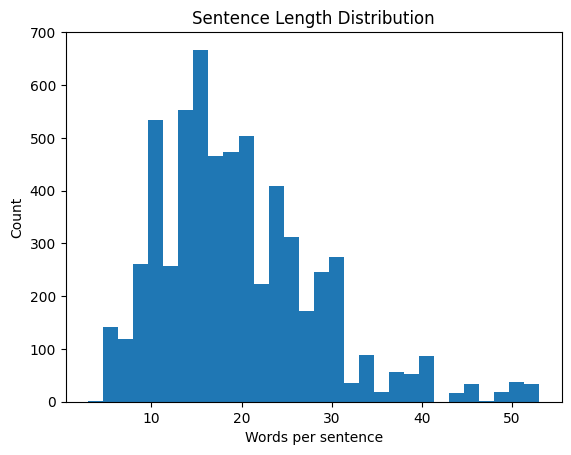

In [4]:
df["num_words"] = df["words"].apply(len)

plt.figure()
plt.hist(df["num_words"], bins=30)
plt.xlabel("Words per sentence")
plt.ylabel("Count")
plt.title("Sentence Length Distribution")
plt.show()

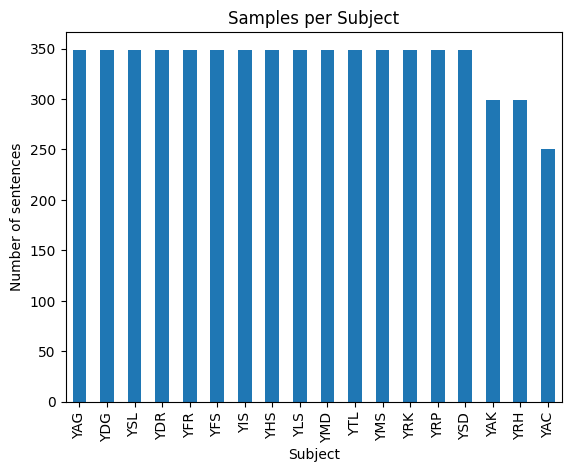

In [5]:
plt.figure()
df["subject_id"].value_counts().plot(kind="bar")
plt.xlabel("Subject")
plt.ylabel("Number of sentences")
plt.title("Samples per Subject")
plt.show()


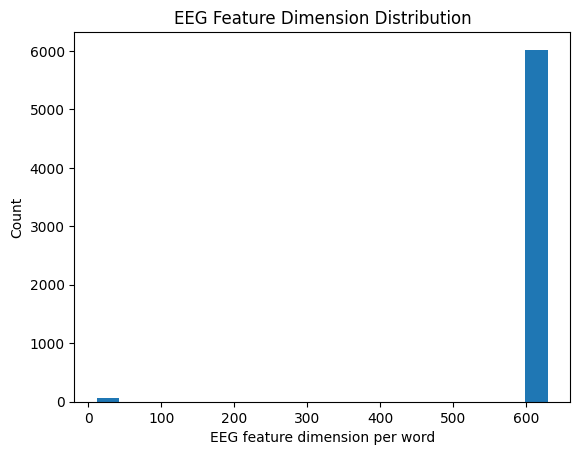

In [6]:
feature_dims = [len(v[0]) for v in df["eeg_vectors"] if len(v) > 0]

plt.figure()
plt.hist(feature_dims, bins=20)
plt.xlabel("EEG feature dimension per word")
plt.ylabel("Count")
plt.title("EEG Feature Dimension Distribution")
plt.show()

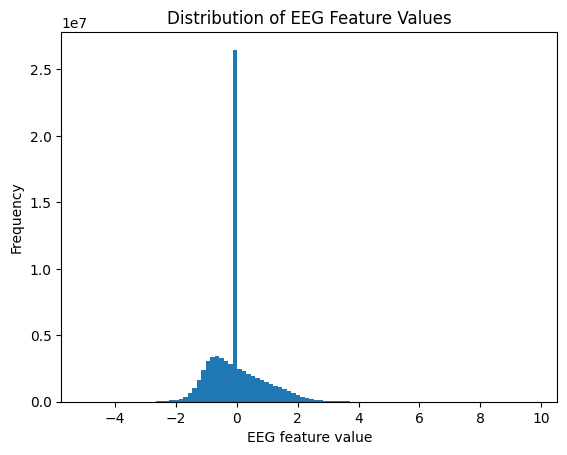

In [14]:
all_eeg_values = []

for sentence in df["eeg_vectors"]:
    for word_vec in sentence:
        all_eeg_values.extend(word_vec)

all_eeg_values = np.array(all_eeg_values)

plt.figure()
plt.hist(all_eeg_values, bins=100)
plt.xlabel("EEG feature value")
plt.ylabel("Frequency")
plt.title("Distribution of EEG Feature Values")
plt.show()


Time-Like Sentence Progression (Word Order Dynamics)

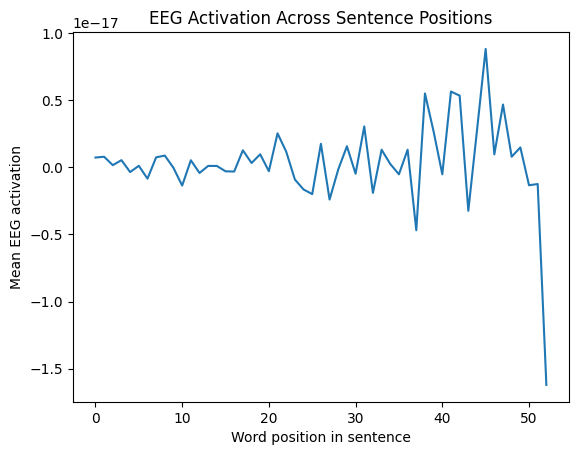

In [8]:
mean_word_eeg = []

for eeg in df["eeg_vectors"]:
    word_means = [np.mean(v) for v in eeg]
    mean_word_eeg.append(word_means)

max_len = max(len(x) for x in mean_word_eeg)

padded = np.array([
    x + [np.nan] * (max_len - len(x))
    for x in mean_word_eeg
])

plt.figure()
plt.plot(np.nanmean(padded, axis=0))
plt.xlabel("Word position in sentence")
plt.ylabel("Mean EEG activation")
plt.title("EEG Activation Across Sentence Positions")
plt.show()

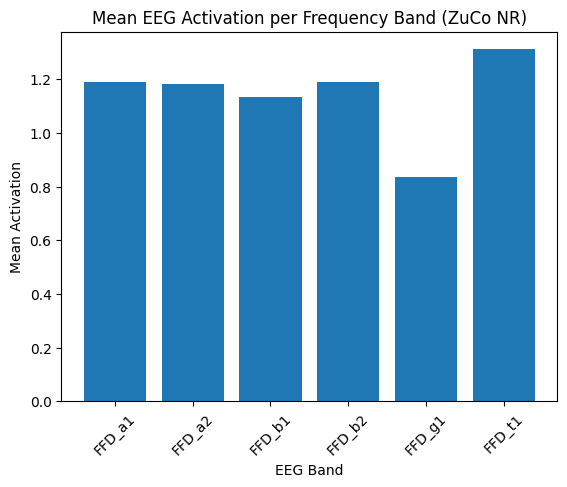

In [19]:
df_raw = pd.read_pickle("zuco2_nr_eeg_text_pairs.pkl")

band_names = ["FFD_a1", "FFD_a2", "FFD_b1", "FFD_b2", "FFD_g1", "FFD_t1"]
band_values = {band: [] for band in band_names}

for eeg_dicts in df_raw["eeg_features_per_word"]:
    for eeg_dict in eeg_dicts:
        for band in band_names:
            if band in eeg_dict:
                vec = np.array(eeg_dict[band])
                if vec.size > 0 and not np.all(np.isnan(vec)):
                    band_values[band].append(np.mean(vec))

band_means = {band: np.mean(vals) for band, vals in band_values.items()}

plt.figure()
plt.bar(band_means.keys(), band_means.values())
plt.xticks(rotation=45)
plt.xlabel("EEG Band")
plt.ylabel("Mean Activation")
plt.title("Mean EEG Activation per Frequency Band (ZuCo NR)")
plt.show()

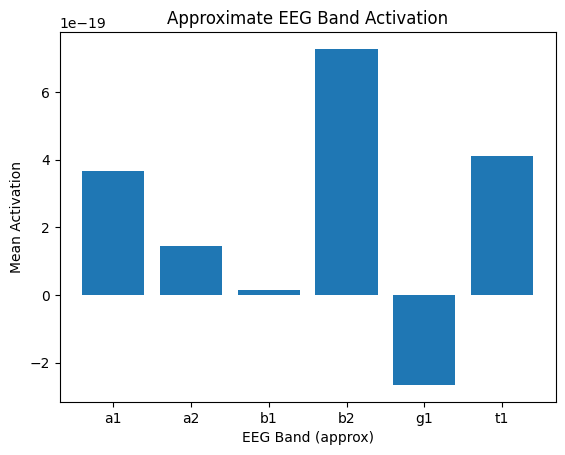

In [20]:
band_names = ["a1", "a2", "b1", "b2", "g1", "t1"]
band_means = {band: [] for band in band_names}

for sentence in df["eeg_vectors"]:
    for word_vec in sentence:
        chunk = np.array(word_vec)
        splits = np.array_split(chunk, len(band_names))
        for band, part in zip(band_names, splits):
            band_means[band].append(np.mean(part))

band_means = {k: np.mean(v) for k, v in band_means.items()}

plt.figure()
plt.bar(band_means.keys(), band_means.values())
plt.xlabel("EEG Band (approx)")
plt.ylabel("Mean Activation")
plt.title("Approximate EEG Band Activation")
plt.show()

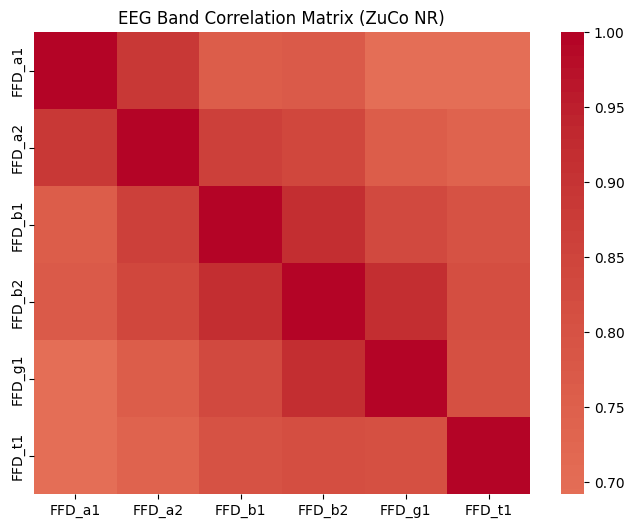

In [21]:
bands = ["FFD_a1", "FFD_a2", "FFD_b1", "FFD_b2", "FFD_g1", "FFD_t1"]
band_data = {b: [] for b in bands}

for eeg_dicts in df_raw["eeg_features_per_word"]:
    for eeg_dict in eeg_dicts:
        for b in bands:
            if b in eeg_dict:
                vec = np.array(eeg_dict[b])
                if vec.size > 0 and not np.all(np.isnan(vec)):
                    band_data[b].append(np.mean(vec))

band_matrix = np.vstack([band_data[b] for b in bands]).T
corr = np.corrcoef(band_matrix, rowvar=False)

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    xticklabels=bands,
    yticklabels=bands,
    cmap="coolwarm",
    center=0
)
plt.title("EEG Band Correlation Matrix (ZuCo NR)")
plt.show()

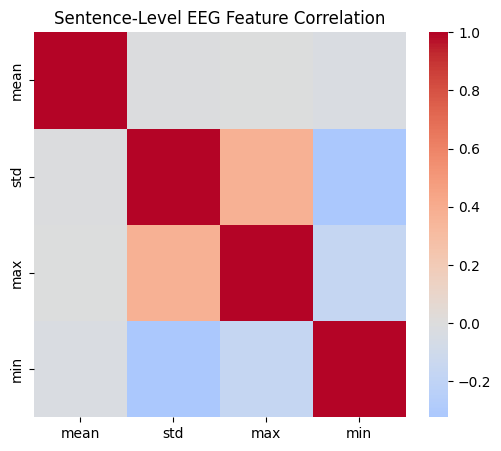

In [22]:
sentence_features = []

for sentence in df["eeg_vectors"]:
    flat = np.concatenate(sentence)
    sentence_features.append([
        np.mean(flat),
        np.std(flat),
        np.max(flat),
        np.min(flat)
    ])

sentence_features = np.array(sentence_features)

corr = np.corrcoef(sentence_features.T)

plt.figure(figsize=(6,5))
sns.heatmap(
    corr,
    xticklabels=["mean", "std", "max", "min"],
    yticklabels=["mean", "std", "max", "min"],
    cmap="coolwarm",
    center=0
)
plt.title("Sentence-Level EEG Feature Correlation")
plt.show()

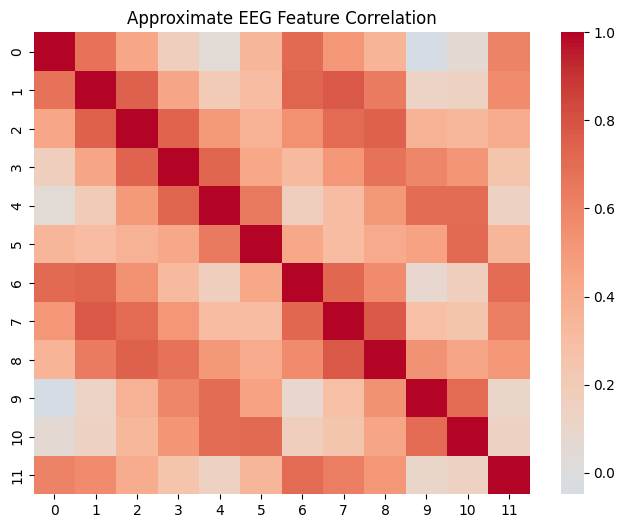

In [23]:
feature_vectors = []

for sentence in df["eeg_vectors"]:
    for word_vec in sentence:
        feature_vectors.append(np.array(word_vec))

# choose a common dimension
min_dim = min(len(v) for v in feature_vectors)
feature_vectors = np.array([v[:min_dim] for v in feature_vectors])

corr = np.corrcoef(feature_vectors.T)

plt.figure(figsize=(8,6))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Approximate EEG Feature Correlation")
plt.show()

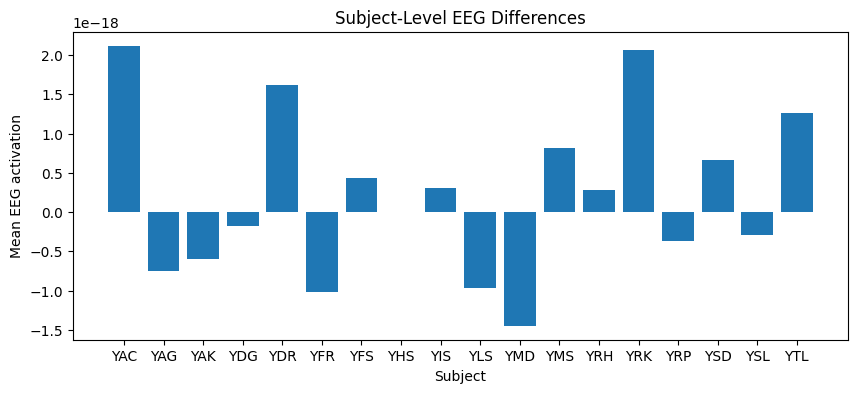

In [24]:
subject_means = {}

for subject in df["subject_id"].unique():
    subject_sentences = df[df["subject_id"] == subject]["eeg_vectors"]

    values = []
    for sentence in subject_sentences:
        for word_vec in sentence:
            values.extend(word_vec)

    subject_means[subject] = np.mean(values)

plt.figure(figsize=(10,4))
plt.bar(subject_means.keys(), subject_means.values())
plt.xlabel("Subject")
plt.ylabel("Mean EEG activation")
plt.title("Subject-Level EEG Differences")
plt.show()

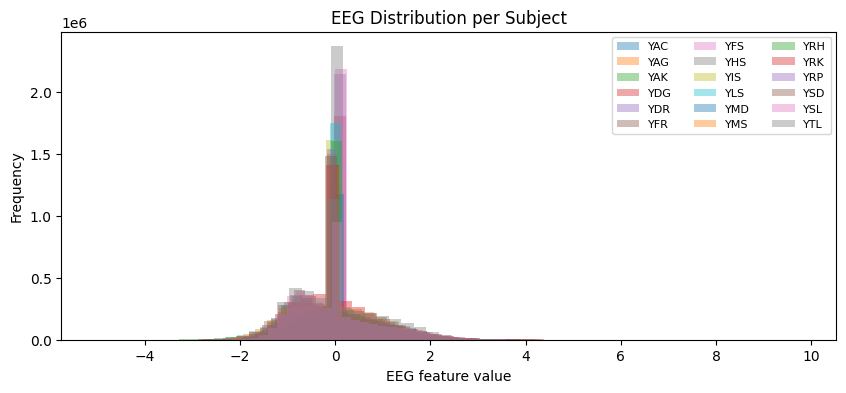

In [25]:
plt.figure(figsize=(10,4))

for subject in df["subject_id"].unique():
    values = []
    for sentence in df[df["subject_id"] == subject]["eeg_vectors"]:
        for word_vec in sentence:
            values.extend(word_vec)
    plt.hist(values, bins=50, alpha=0.4, label=subject)

plt.xlabel("EEG feature value")
plt.ylabel("Frequency")
plt.title("EEG Distribution per Subject")
plt.legend(ncol=3, fontsize=8)
plt.show()

In [26]:
bands = ["FFD_a1", "FFD_a2", "FFD_b1", "FFD_b2", "FFD_g1", "FFD_t1"]
band_values = {b: [] for b in bands}

for eeg_dicts in df_raw["eeg_features_per_word"]:
    for eeg_dict in eeg_dicts:
        for b in bands:
            if b in eeg_dict:
                vec = np.array(eeg_dict[b])
                if vec.size > 0 and not np.all(np.isnan(vec)):
                    band_values[b].append(np.mean(vec))

# Make matrix: (samples × bands)
band_matrix = np.vstack([band_values[b] for b in bands]).T

# Correlation between bands
corr = np.corrcoef(band_matrix, rowvar=False)

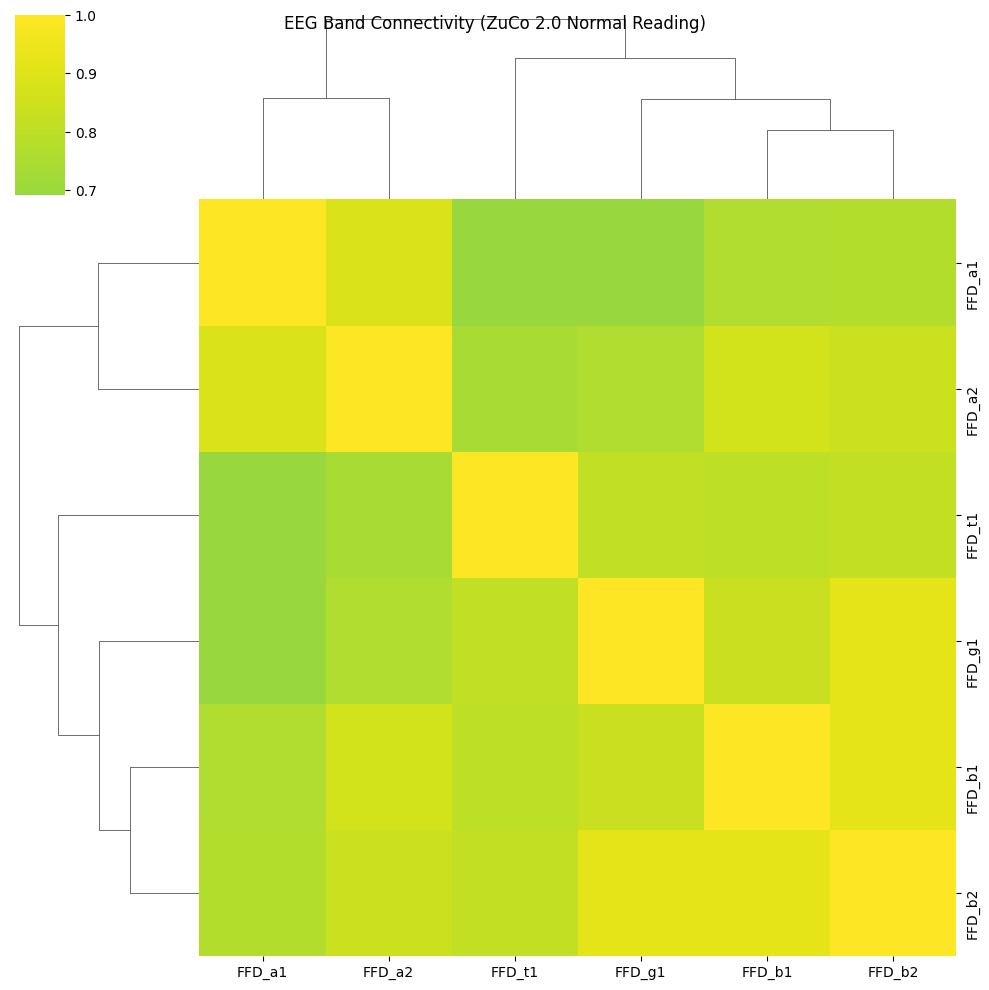

In [27]:
sns.clustermap(
    corr,
    xticklabels=bands,
    yticklabels=bands,
    cmap="viridis",
    center=0
)
plt.suptitle("EEG Band Connectivity (ZuCo 2.0 Normal Reading)")
plt.show()

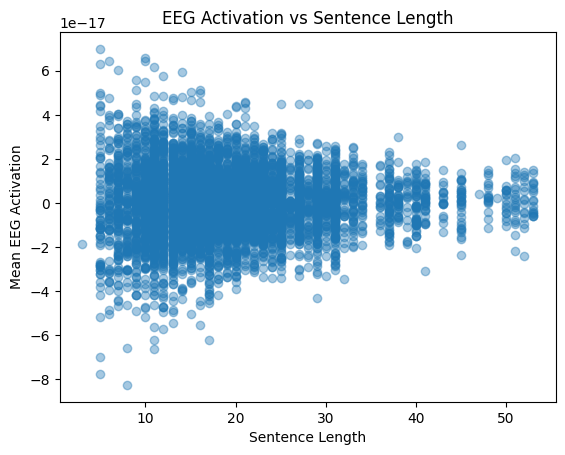

In [13]:
sentence_eeg_mean = [
    np.mean(np.vstack(eeg)) for eeg in df["eeg_vectors"]
]

plt.figure()
plt.scatter(df["num_words"], sentence_eeg_mean, alpha=0.4)
plt.xlabel("Sentence Length")
plt.ylabel("Mean EEG Activation")
plt.title("EEG Activation vs Sentence Length")
plt.show()

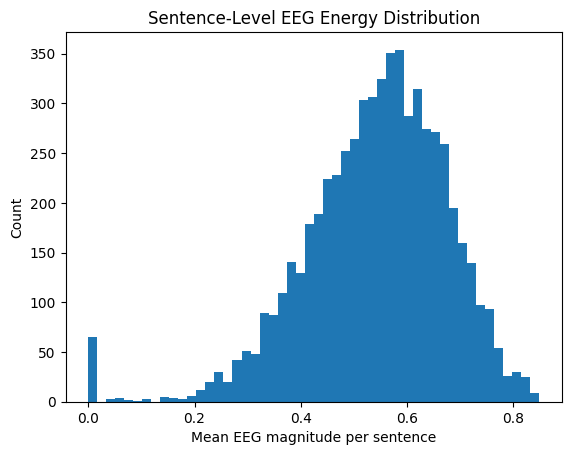

In [16]:
sentence_energy = [
    np.mean(np.abs(np.concatenate(sentence)))
    for sentence in df["eeg_vectors"]
]

plt.figure()
plt.hist(sentence_energy, bins=50)
plt.xlabel("Mean EEG magnitude per sentence")
plt.ylabel("Count")
plt.title("Sentence-Level EEG Energy Distribution")
plt.show()

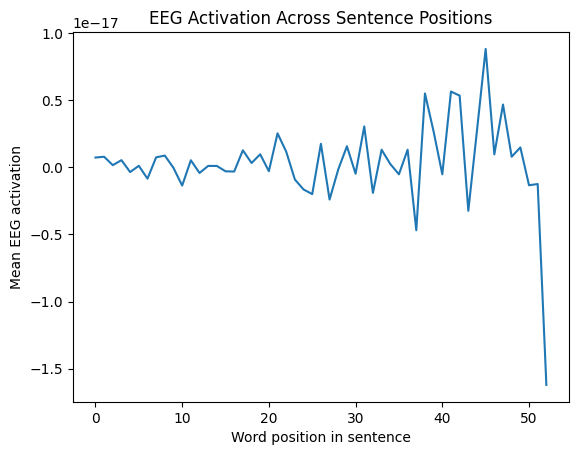

In [17]:
mean_word_eeg = []

for sentence in df["eeg_vectors"]:
    mean_word_eeg.append([np.mean(w) for w in sentence])

max_len = max(len(x) for x in mean_word_eeg)

padded = np.array([
    x + [np.nan] * (max_len - len(x))
    for x in mean_word_eeg
])

plt.figure()
plt.plot(np.nanmean(padded, axis=0))
plt.xlabel("Word position in sentence")
plt.ylabel("Mean EEG activation")
plt.title("EEG Activation Across Sentence Positions")
plt.show()